<a href="https://colab.research.google.com/github/bhanuprakash227/DataScience_ExcelR_Assignments/blob/main/7_MLR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Multiple Linear Regression**

**Load and Explore Dataset**

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler,MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
df=pd.read_csv("ToyotaCorolla - MLR.csv")
print("Dataset Shape:",df.shape)
print("\nFirst 5 Rows:")
print(df.head())
print("\nSummary Statistics:")
print(df.describe(include="all"))
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:",df.duplicated().sum())
df=df.drop_duplicates()
print("\nDataset Shape After Removing Duplicates:",df.shape)

Dataset Shape: (1436, 11)

First 5 Rows:
   Price  Age_08_04     KM Fuel_Type  HP  Automatic    cc  Doors  Cylinders  \
0  13500         23  46986    Diesel  90          0  2000      3          4   
1  13750         23  72937    Diesel  90          0  2000      3          4   
2  13950         24  41711    Diesel  90          0  2000      3          4   
3  14950         26  48000    Diesel  90          0  2000      3          4   
4  13750         30  38500    Diesel  90          0  2000      3          4   

   Gears  Weight  
0      5    1165  
1      5    1165  
2      5    1165  
3      5    1165  
4      5    1170  

Summary Statistics:
               Price    Age_08_04             KM Fuel_Type           HP  \
count    1436.000000  1436.000000    1436.000000      1436  1436.000000   
unique           NaN          NaN            NaN         3          NaN   
top              NaN          NaN            NaN    Petrol          NaN   
freq             NaN          NaN            NaN 

**Exploratory Data Analysis and Visualizations**

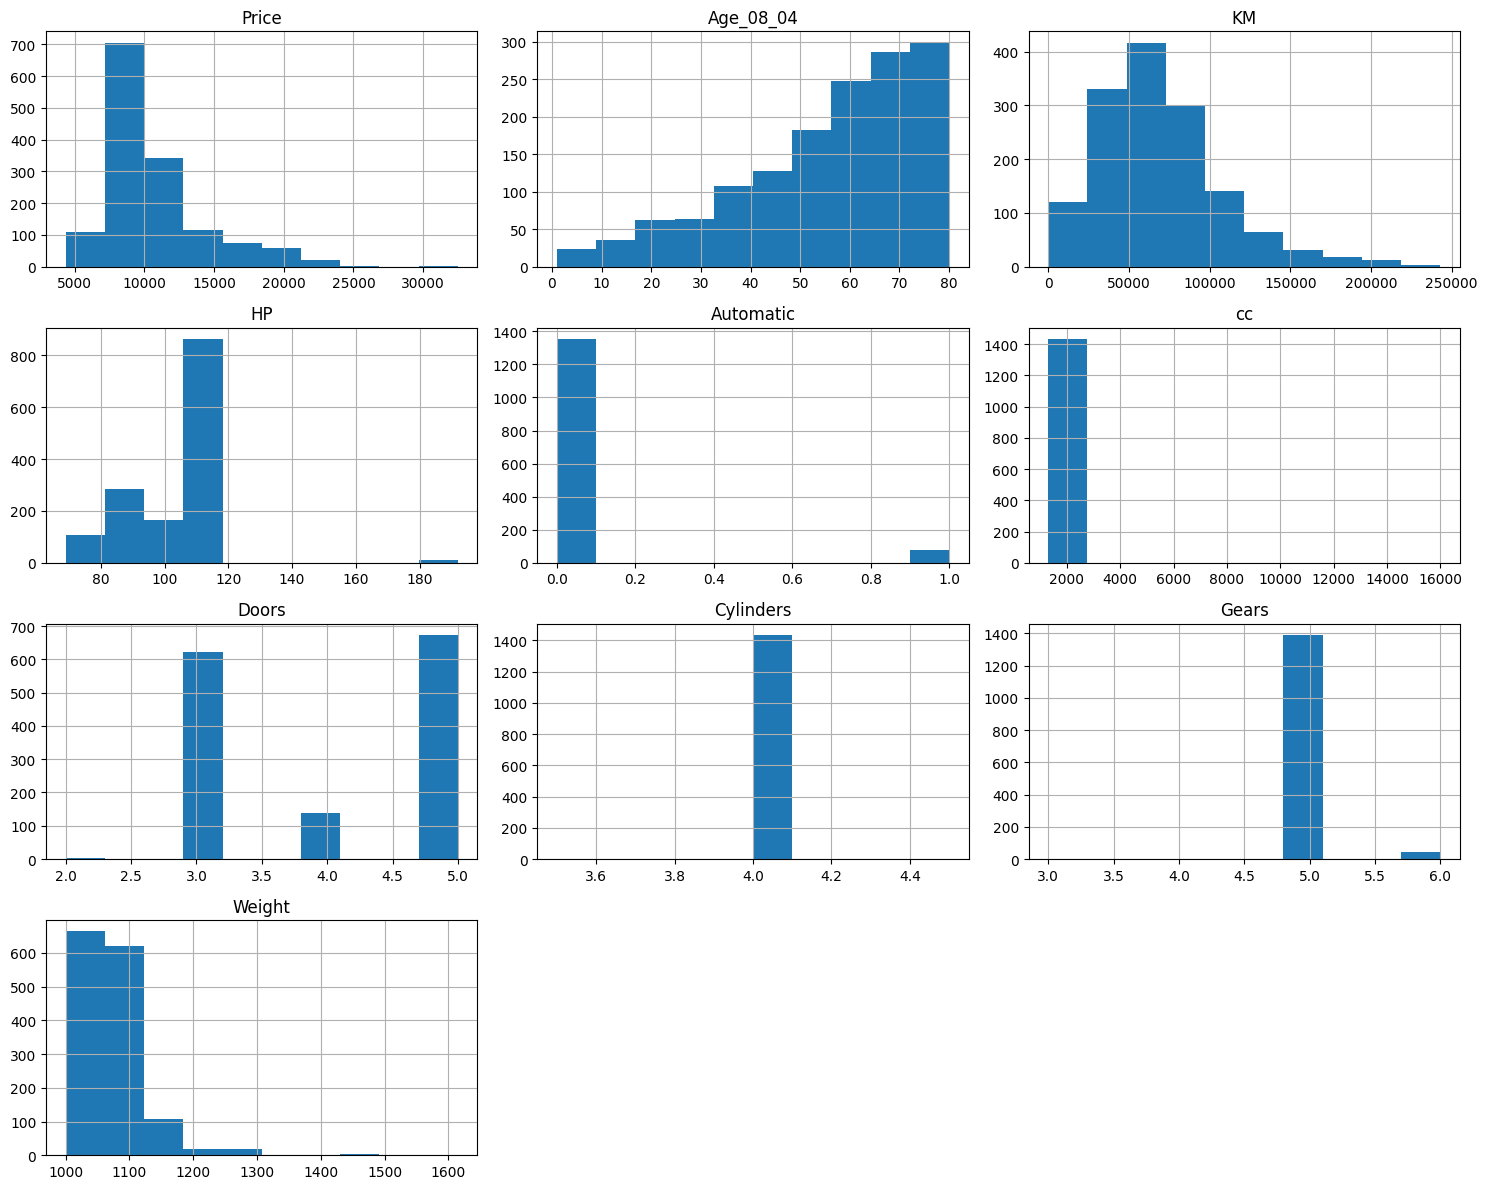

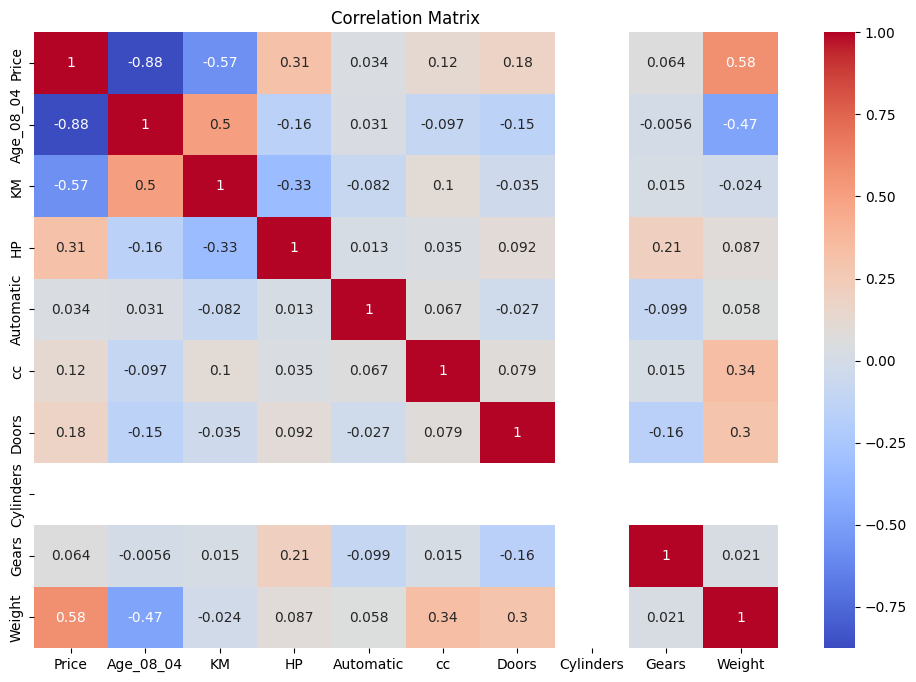

In [15]:

numeric_cols=df.select_dtypes(include=np.number).columns
df[numeric_cols].hist(figsize=(15,12))
plt.tight_layout()
plt.show()
plt.figure(figsize=(12,8))
sns.heatmap(df[numeric_cols].corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

**Data Preprocessing and Train-Test Split**

In [16]:

target="Price"
X=df.drop(columns=[target])
y=df[target]
categorical_cols=X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols=X.select_dtypes(include=np.number).columns.tolist()
print("Categorical Columns:",categorical_cols)
print("Numerical Columns:",numeric_cols)
preprocessor=ColumnTransformer([("numeric",StandardScaler(),numeric_cols),("categorical",OneHotEncoder(handle_unknown="ignore"),categorical_cols)])
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)
print("Training Samples:",len(X_train))
print("Testing Samples:",len(X_test))

Categorical Columns: ['Fuel_Type']
Numerical Columns: ['Age_08_04', 'KM', 'HP', 'Automatic', 'cc', 'Doors', 'Cylinders', 'Gears', 'Weight']
Training Samples: 1148
Testing Samples: 287


**Build Three Multiple Linear Regression Models**

In [17]:

models={}
models["Model 1 - All Features"]=Pipeline([("preprocessor",preprocessor),("model",LinearRegression())])
features2=[c for c in ["Age","KM","HP","CC","Weight","Quarterly_Tax"] if c in X.columns]
X2=X[features2]
X2_train,X2_test,y2_train,y2_test=train_test_split(X2,y,test_size=0.20,random_state=42)
preprocessor2=ColumnTransformer([("numeric",StandardScaler(),features2)])
models["Model 2 - Selected Features"]=Pipeline([("preprocessor",preprocessor2),("model",LinearRegression())])
features3=[c for c in ["Age","KM","HP","Weight"] if c in X.columns]
X3=X[features3]
X3_train,X3_test,y3_train,y3_test=train_test_split(X3,y,test_size=0.20,random_state=42)
preprocessor3=ColumnTransformer([("numeric",StandardScaler(),features3)])
models["Model 3 - Reduced Features"]=Pipeline([("preprocessor",preprocessor3),("model",LinearRegression())])

**Evaluate Three Regression Models**

In [18]:

results=[]
for name,model in models.items():
    if name=="Model 1 - All Features":
        model.fit(X_train,y_train)
        predictions=model.predict(X_test)
        actual=y_test
    elif name=="Model 2 - Selected Features":
        model.fit(X2_train,y2_train)
        predictions=model.predict(X2_test)
        actual=y2_test
    else:
        model.fit(X3_train,y3_train)
        predictions=model.predict(X3_test)
        actual=y3_test
    mae=mean_absolute_error(actual,predictions)
    mse=mean_squared_error(actual,predictions)
    rmse=np.sqrt(mse)
    r2=r2_score(actual,predictions)
    results.append([name,mae,mse,rmse,r2])
results_df=pd.DataFrame(results,columns=["Model","MAE","MSE","RMSE","R2"])
print(results_df)

                         Model          MAE           MSE         RMSE  \
0       Model 1 - All Features   986.496688  2.155628e+06  1468.205829   
1  Model 2 - Selected Features  1618.910757  5.177817e+06  2275.481698   
2   Model 3 - Reduced Features  1618.910757  5.177817e+06  2275.481698   

         R2  
0  0.820321  
1  0.568412  
2  0.568412  


**Interpret Model Coefficients**

In [19]:

print("Model Coefficients:")
for name,model in models.items():
    print("\n",name)
    fitted_model=model.named_steps["model"]
    transformed_columns=model.named_steps["preprocessor"].get_feature_names_out()
    coefficients=fitted_model.coef_
    coefficient_df=pd.DataFrame({"Feature":transformed_columns,"Coefficient":coefficients})
    coefficient_df["Absolute_Coefficient"]=abs(coefficient_df["Coefficient"])
    print(coefficient_df.sort_values("Absolute_Coefficient",ascending=False).drop(columns="Absolute_Coefficient").head(15))
    print("Intercept:",fitted_model.intercept_)

Model Coefficients:

 Model 1 - All Features
                          Feature   Coefficient
0              numeric__Age_08_04 -2.266203e+03
8                 numeric__Weight  1.333183e+03
11  categorical__Fuel_Type_Petrol  8.825167e+02
10  categorical__Fuel_Type_Diesel -6.361002e+02
1                     numeric__KM -6.043518e+02
9      categorical__Fuel_Type_CNG -2.464164e+02
2                     numeric__HP  2.416137e+02
5                  numeric__Doors -8.381028e+01
7                  numeric__Gears  8.087422e+01
3              numeric__Automatic  5.982922e+01
4                     numeric__cc -2.191795e+01
6              numeric__Cylinders  5.684342e-13
Intercept: 10023.991062896612

 Model 2 - Selected Features
           Feature  Coefficient
2  numeric__Weight  2052.268505
0      numeric__KM -1928.169901
1      numeric__HP   327.459898
Intercept: 10727.046167247383

 Model 3 - Reduced Features
           Feature  Coefficient
2  numeric__Weight  2052.268505
0      numeric__KM -

**Normalization and Standardization**

In [20]:

normalizer=MinMaxScaler()
standardizer=StandardScaler()
sample_data=df[numeric_cols].drop(columns=[target],errors="ignore").dropna()
normalized_data=normalizer.fit_transform(sample_data)
standardized_data=standardizer.fit_transform(sample_data)
print("Normalization converts values approximately to the range 0 to 1.")
print("Standardization converts values to mean 0 and standard deviation 1.")
print("\nNormalized Data:")
print(pd.DataFrame(normalized_data,columns=sample_data.columns).head())
print("\nStandardized Data:")
print(pd.DataFrame(standardized_data,columns=sample_data.columns).head())

Normalization converts values approximately to the range 0 to 1.
Standardization converts values to mean 0 and standard deviation 1.

Normalized Data:
   Age_08_04        KM        HP  Automatic        cc     Doors  Cylinders  \
0   0.278481  0.193355  0.170732        0.0  0.047619  0.333333        0.0   
1   0.278481  0.300149  0.170732        0.0  0.047619  0.333333        0.0   
2   0.291139  0.171647  0.170732        0.0  0.047619  0.333333        0.0   
3   0.316456  0.197528  0.170732        0.0  0.047619  0.333333        0.0   
4   0.367089  0.158433  0.170732        0.0  0.047619  0.333333        0.0   

      Gears    Weight  
0  0.666667  0.268293  
1  0.666667  0.268293  
2  0.666667  0.268293  
3  0.666667  0.268293  
4  0.666667  0.276423  

Standardized Data:
   Age_08_04        KM        HP  Automatic        cc     Doors  Cylinders  \
0  -1.777268 -0.575958 -0.767351  -0.242983  0.998113 -1.084443        0.0   
1  -1.777268  0.116474 -0.767351  -0.242983  0.998113 -1.084

In [21]:
# Assignment 7: Multicollinearity Check Using VIF
vif_data=df[numeric_cols].drop(columns=[target],errors="ignore").dropna()
if vif_data.shape[1]>1:
    vif_df=pd.DataFrame()
    vif_df["Feature"]=vif_data.columns
    vif_df["VIF"]=[variance_inflation_factor(vif_data.values,i) for i in range(vif_data.shape[1])]
    print(vif_df)
print("\nMulticollinearity can be addressed by removing highly correlated variables, using VIF analysis, applying PCA, or using Lasso and Ridge regularization.")

     Feature       VIF
0  Age_08_04  1.901144
1         KM  1.678436
2         HP  1.217309
3  Automatic  1.048017
4         cc  1.150257
5      Doors  1.154944
6  Cylinders  1.000000
7      Gears  1.109310
8     Weight  1.659263

Multicollinearity can be addressed by removing highly correlated variables, using VIF analysis, applying PCA, or using Lasso and Ridge regularization.


**Lasso and Ridge Regression**

In [22]:

lasso=Pipeline([("preprocessor",preprocessor2),("model",Lasso(alpha=0.1,max_iter=10000))])
ridge=Pipeline([("preprocessor",preprocessor2),("model",Ridge(alpha=1.0))])
lasso.fit(X2_train,y2_train)
ridge.fit(X2_train,y2_train)
lasso_pred=lasso.predict(X2_test)
ridge_pred=ridge.predict(X2_test)
print("Lasso Regression")
print("MAE:",mean_absolute_error(y2_test,lasso_pred))
print("MSE:",mean_squared_error(y2_test,lasso_pred))
print("RMSE:",np.sqrt(mean_squared_error(y2_test,lasso_pred)))
print("R2:",r2_score(y2_test,lasso_pred))
print("\nRidge Regression")
print("MAE:",mean_absolute_error(y2_test,ridge_pred))
print("MSE:",mean_squared_error(y2_test,ridge_pred))
print("RMSE:",np.sqrt(mean_squared_error(y2_test,ridge_pred)))
print("R2:",r2_score(y2_test,ridge_pred))

Lasso Regression
MAE: 1618.9153187143909
MSE: 5177681.900305335
RMSE: 2275.452021095003
R2: 0.5684234252290643

Ridge Regression
MAE: 1618.997197261788
MSE: 5175426.860311801
RMSE: 2274.9564523989907
R2: 0.5686113901243823


**Regression Assumptions and Implications**

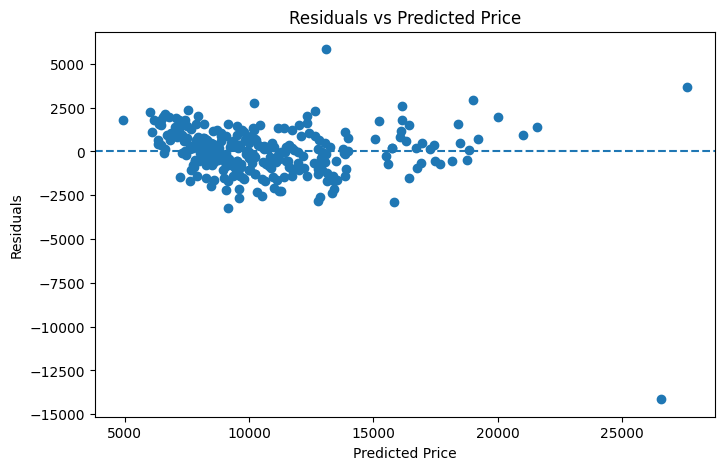

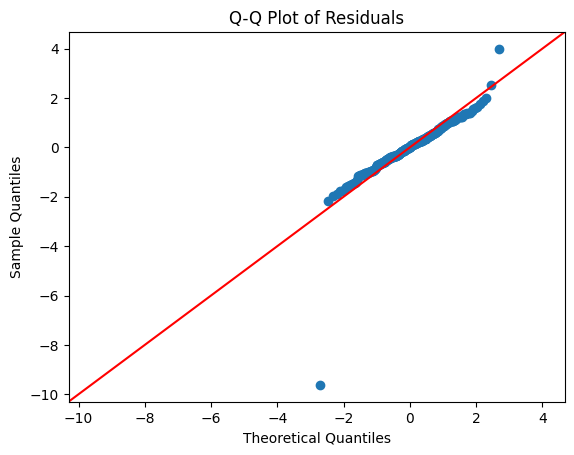

Assumption 1: A linear relationship should exist between predictors and Price.
Assumption 2: Residuals should have approximately constant variance.
Assumption 3: Residuals should be approximately normally distributed.
Assumption 4: Observations should be independent.
Violations of these assumptions can affect coefficient interpretation, statistical inference, and prediction performance.

Assignment 7 completed: EDA, preprocessing, train-test split, 3 MLR models, coefficient interpretation, evaluation metrics, Lasso, Ridge, normalization, standardization, multicollinearity, assumptions, and implications.


In [23]:

best_model=models["Model 1 - All Features"]
best_predictions=best_model.predict(X_test)
residuals=y_test-best_predictions
plt.figure(figsize=(8,5))
plt.scatter(best_predictions,residuals)
plt.axhline(0,linestyle="--")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Price")
plt.show()
sm.qqplot(residuals,line="45",fit=True)
plt.title("Q-Q Plot of Residuals")
plt.show()
print("Assumption 1: A linear relationship should exist between predictors and Price.")
print("Assumption 2: Residuals should have approximately constant variance.")
print("Assumption 3: Residuals should be approximately normally distributed.")
print("Assumption 4: Observations should be independent.")
print("Violations of these assumptions can affect coefficient interpretation, statistical inference, and prediction performance.")
print("\nAssignment 7 completed: EDA, preprocessing, train-test split, 3 MLR models, coefficient interpretation, evaluation metrics, Lasso, Ridge, normalization, standardization, multicollinearity, assumptions, and implications.")